<a href="https://colab.research.google.com/github/aabyyaann/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter4_Representing_Data_and_Engineering_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 - Representing Data and Engineering Features

Notebook ini merangkum dan mereproduksi inti Chapter 4 dari buku **Introduction to Machine Learning with Python** karya Andreas C. Müller & Sarah Guido.

Pada chapter ini, fokus utama adalah bagaimana **merepresentasikan data** agar bisa dipahami oleh model machine learning, serta bagaimana melakukan **feature engineering** untuk meningkatkan performa model.

Topik utama pada chapter ini:
1. Representing Categorical Data
2. One-Hot Encoding
3. Binning / Discretization
4. Interaction and Polynomial Features
5. Feature Selection

Notebook ini dibuat untuk kebutuhan reproduksi kode sekaligus ringkasan teori dari buku.

## 1. Import Library

Pada bagian ini kita mengimpor library yang akan digunakan untuk eksplorasi data, visualisasi, preprocessing, feature engineering, dan evaluasi model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.feature_selection import SelectPercentile, f_classif, SelectFromModel
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

print("Library Chapter 4 siap digunakan.")

Library Chapter 4 siap digunakan.


## 2. Representing Categorical Variables

Dalam machine learning, model umumnya bekerja pada **data numerik**. Oleh karena itu, jika dataset memiliki fitur kategorikal seperti `"male/female"` atau `"red/blue/green"`, maka fitur tersebut harus diubah ke bentuk numerik.

Salah satu pendekatan paling umum adalah **One-Hot Encoding**, yaitu membuat kolom biner untuk setiap kategori unik.

Sebagai contoh:
- color = red, green, blue  
akan diubah menjadi:
- color_red
- color_green
- color_blue

In [2]:
# Contoh dataset sederhana dengan fitur kategorikal
demo_data = pd.DataFrame({
    "age": [25, 32, 47, 51],
    "city": ["Jakarta", "Bandung", "Jakarta", "Surabaya"],
    "owns_house": ["yes", "no", "yes", "no"]
})

demo_data

,age,city,owns_house
0,25,Jakarta,yes
1,32,Bandung,no
2,47,Jakarta,yes
3,51,Surabaya,no


Dataset di atas memiliki dua fitur kategorikal:
- `city`
- `owns_house`

Jika kita langsung memberikan data ini ke model machine learning, sebagian besar model akan error karena model tidak memahami string/kategori secara langsung.

In [3]:
# One-hot encoding menggunakan pandas
demo_encoded = pd.get_dummies(demo_data)
demo_encoded

,age,city_Bandung,city_Jakarta,city_Surabaya,owns_house_no,owns_house_yes
0,25,False,True,False,False,True
1,32,True,False,False,True,False
2,47,False,True,False,False,True
3,51,False,False,True,True,False


Hasil one-hot encoding menunjukkan bahwa setiap kategori diubah menjadi kolom biner. Misalnya:
- `city_Bandung`
- `city_Jakarta`
- `city_Surabaya`

Nilai 1 menandakan bahwa baris tersebut memiliki kategori itu, sedangkan 0 berarti tidak.

Teknik ini sangat penting karena banyak model machine learning hanya menerima input numerik.

## 3. Effect of One-Hot Encoding on Machine Learning

Sekarang kita akan melihat bagaimana fitur kategorikal dapat digunakan dalam model machine learning setelah diubah ke bentuk numerik.

Kita buat contoh dataset kecil dengan target numerik, lalu kita bandingkan bagaimana model memanfaatkan fitur hasil encoding.

In [4]:
# Dataset sederhana untuk regresi
data = pd.DataFrame({
    "age": [20, 25, 30, 35, 40, 45],
    "city": ["A", "B", "A", "B", "C", "C"],
    "income": [3, 4, 5, 6, 7, 8]
})

data

,age,city,income
0,20,A,3
1,25,B,4
2,30,A,5
3,35,B,6
4,40,C,7
5,45,C,8


In [5]:
X = data[["age", "city"]]
y = data["income"]

X_encoded = pd.get_dummies(X)
X_encoded

,age,city_A,city_B,city_C
0,20,True,False,False
1,25,False,True,False
2,30,True,False,False
3,35,False,True,False
4,40,False,False,True
5,45,False,False,True


In [6]:
model = LinearRegression()
model.fit(X_encoded, y)

print("Koefisien model:")
for name, coef in zip(X_encoded.columns, model.coef_):
    print(f"{name}: {coef:.3f}")

print("Intercept:", model.intercept_)

Koefisien model:
age: 0.200
city_A: 0.000
city_B: 0.000
city_C: -0.000
Intercept: -0.9999999999999991


Koefisien di atas menunjukkan bagaimana model linear menggunakan fitur numerik dan hasil one-hot encoding untuk membuat prediksi.

Inti dari bagian ini adalah:
- model linear tidak bisa langsung menerima string
- categorical feature harus diubah ke representasi numerik
- one-hot encoding adalah teknik paling umum

## 4. Binning / Discretization

Selain mengubah kategori menjadi angka, Chapter 4 juga membahas bagaimana **fitur numerik kontinu** dapat diubah menjadi beberapa interval (bin).

Contoh:
- umur 0–20 → kelompok 1
- umur 21–40 → kelompok 2
- umur 41–60 → kelompok 3

Proses ini disebut **discretization** atau **binning**.

Tujuan binning:
- menyederhanakan pola non-linear
- membantu model linear menangkap pola yang tidak lurus
- membuat interpretasi lebih mudah

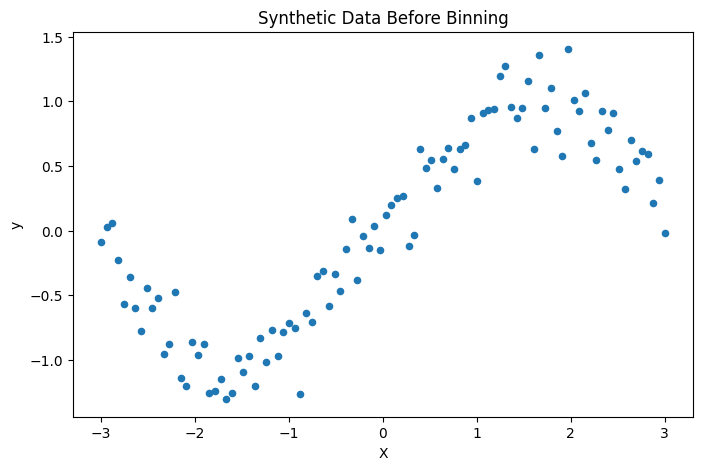

In [7]:
# Membuat data sintetis sederhana
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(scale=0.2, size=len(X))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=20)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data Before Binning")
plt.show()

Data di atas memiliki hubungan non-linear. Jika kita memakai model linear biasa, model mungkin kesulitan menangkap bentuk sinusoidal tersebut.

Salah satu pendekatan sederhana adalah membagi sumbu X menjadi beberapa interval, lalu menggunakan hasil interval itu sebagai fitur baru.

In [8]:
# Ubah ke bentuk 2D agar kompatibel dengan sklearn
X_reshaped = X.reshape(-1, 1)

# Membuat bin
bins = np.linspace(-3, 3, 11)
which_bin = np.digitize(X, bins=bins)

print("Beberapa hasil binning:")
print(which_bin[:10])

Beberapa hasil binning:
[1 1 1 1 1 1 1 1 1 1]


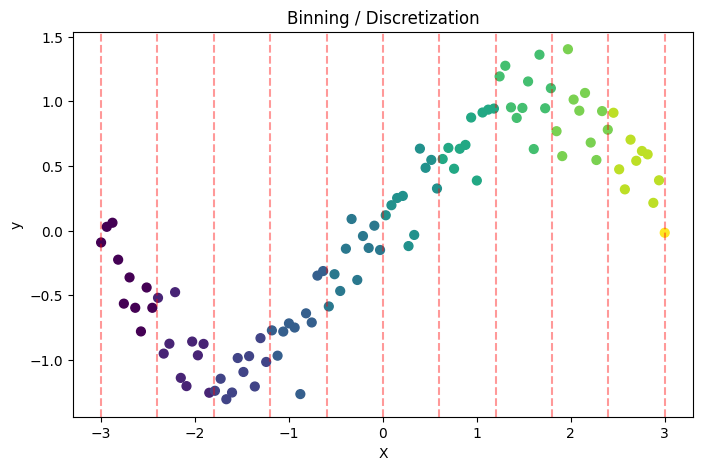

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, c=which_bin, cmap='viridis', s=40)
for bin_edge in bins:
    plt.axvline(bin_edge, color='red', linestyle='--', alpha=0.4)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Binning / Discretization")
plt.show()

Garis vertikal merah menunjukkan batas antar bin. Setiap titik sekarang tidak hanya memiliki nilai kontinu X, tetapi juga informasi interval tempat ia berada.

Selanjutnya, hasil binning ini dapat diubah menjadi representasi biner menggunakan one-hot encoding, sehingga model linear dapat memanfaatkan informasi interval tersebut.

In [10]:
from sklearn.preprocessing import KBinsDiscretizer

kbd = KBinsDiscretizer(n_bins=10, encode='onehot-dense', strategy='uniform')
X_binned = kbd.fit_transform(X_reshaped)

print("Shape data setelah binning + one-hot:", X_binned.shape)
print(X_binned[:5])

Shape data setelah binning + one-hot: (100, 10)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, random_state=0
)

X_train_binned = kbd.fit_transform(X_train)
X_test_binned = kbd.transform(X_test)

lr = LinearRegression().fit(X_train_binned, y_train)

print("Train score:", lr.score(X_train_binned, y_train))
print("Test score :", lr.score(X_test_binned, y_test))

Train score: 0.9150791326561839
Test score : 0.8865606032749804


## 5. Interaction Features and Polynomial Features

Feature engineering tidak hanya berarti membersihkan data, tetapi juga **menciptakan fitur baru** dari fitur yang sudah ada.

Dua pendekatan penting:
1. **Interaction Features**  
   Menggabungkan dua fitur, misalnya:
   \[
   x_1 \times x_2
   \]

2. **Polynomial Features**  
   Menambahkan pangkat fitur, misalnya:
   \[
   x,\ x^2,\ x^3
   \]

Teknik ini sangat membantu model linear untuk menangkap pola non-linear.

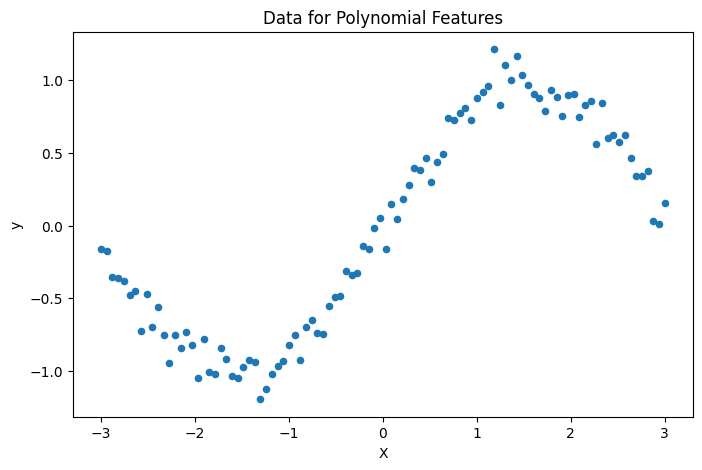

In [12]:
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.1, size=100)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=20)
plt.title("Data for Polynomial Features")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [13]:
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X)

print("Shape sebelum transform:", X.shape)
print("Shape setelah polynomial features:", X_poly.shape)

print("Feature names:")
print(poly.get_feature_names_out(["x"]))

Shape sebelum transform: (100, 1)
Shape setelah polynomial features: (100, 5)
Feature names:
['x' 'x^2' 'x^3' 'x^4' 'x^5']


Setelah transformasi polynomial, satu fitur `x` berubah menjadi beberapa fitur:
- x
- x²
- x³
- x⁴
- x⁵

Dengan fitur-fitur ini, model linear dapat mempelajari hubungan non-linear.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Linear regression biasa
lr = LinearRegression().fit(X_train, y_train)

# Linear regression dengan polynomial features
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression().fit(X_train_poly, y_train)

print("Linear Regression biasa")
print("Train score:", lr.score(X_train, y_train))
print("Test score :", lr.score(X_test, y_test))

print("\nLinear Regression + Polynomial Features")
print("Train score:", lr_poly.score(X_train_poly, y_train))
print("Test score :", lr_poly.score(X_test_poly, y_test))

Linear Regression biasa
Train score: 0.6300810491749056
Test score : 0.6704251487986379

Linear Regression + Polynomial Features
Train score: 0.9818798034300326
Test score : 0.9809725345446968


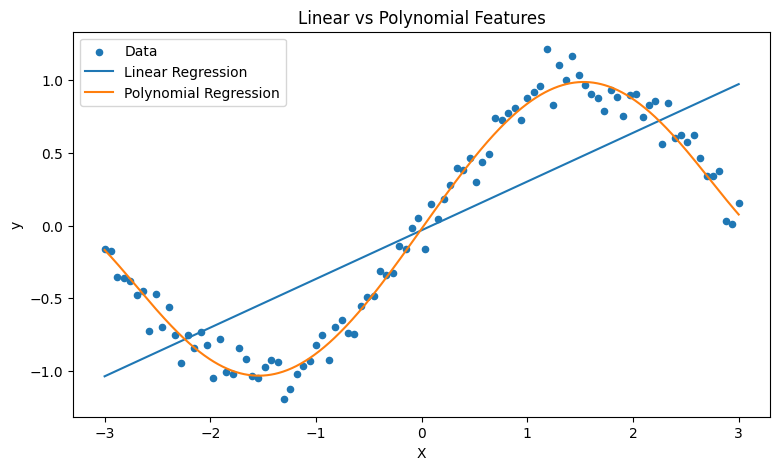

In [15]:
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

plt.figure(figsize=(9, 5))
plt.scatter(X, y, s=20, label="Data")

plt.plot(line, lr.predict(line), label="Linear Regression")

line_poly = poly.transform(line)
plt.plot(line, lr_poly.predict(line_poly), label="Polynomial Regression")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear vs Polynomial Features")
plt.legend()
plt.show()

## 6. Feature Selection

Pada dataset nyata, tidak semua fitur berguna. Beberapa fitur mungkin:
- tidak relevan,
- redundant,
- atau hanya menambah noise.

**Feature selection** adalah proses memilih fitur yang paling penting agar model:
- lebih sederhana,
- lebih cepat,
- lebih mudah diinterpretasi,
- dan kadang lebih akurat.

Chapter ini membahas beberapa pendekatan:
1. **Univariate Statistics**
2. **Model-Based Selection**
3. **Iterative Selection**

### 6.1 Univariate Statistics

Pendekatan ini memilih fitur berdasarkan hubungan statistik masing-masing fitur terhadap target, satu per satu.

Untuk klasifikasi, salah satu metode yang umum adalah **ANOVA F-test**.

In [16]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print("Shape data asli:", X.shape)

Shape data asli: (569, 30)


In [17]:
# Menambahkan noise agar efek feature selection lebih terlihat
rng = np.random.RandomState(42)
noise = rng.normal(size=(len(X), 50))
X_noisy = np.hstack([X, noise])

print("Shape setelah ditambah noise:", X_noisy.shape)

Shape setelah ditambah noise: (569, 80)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y, random_state=0
)

select = SelectPercentile(score_func=f_classif, percentile=50)
select.fit(X_train, y_train)

X_train_selected = select.transform(X_train)
X_test_selected = select.transform(X_test)

print("Shape X_train sebelum seleksi:", X_train.shape)
print("Shape X_train sesudah seleksi:", X_train_selected.shape)

Shape X_train sebelum seleksi: (426, 80)
Shape X_train sesudah seleksi: (426, 40)


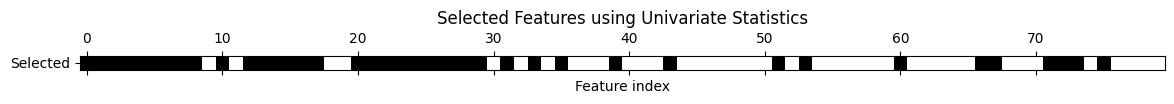

In [19]:
mask = select.get_support()

plt.figure(figsize=(14, 4))
plt.matshow(mask.reshape(1, -1), cmap='gray_r', fignum=False)
plt.xlabel("Feature index")
plt.yticks([0], ["Selected"])
plt.title("Selected Features using Univariate Statistics")
plt.show()

Visualisasi di atas menunjukkan fitur mana saja yang dipilih oleh metode univariate statistics. Nilai terang menunjukkan fitur yang dipertahankan, sedangkan nilai gelap menunjukkan fitur yang dibuang.

In [20]:
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train, y_train)
print("Score all features:", logreg.score(X_test, y_test))

logreg.fit(X_train_selected, y_train)
print("Score selected features:", logreg.score(X_test_selected, y_test))

Score all features: 0.9440559440559441
Score selected features: 0.9440559440559441


Jika performa model dengan fitur terpilih tetap baik atau bahkan meningkat, maka feature selection berhasil menyederhanakan model tanpa kehilangan informasi penting.

### 6.2 Model-Based Feature Selection

Pendekatan ini menggunakan model machine learning untuk menentukan pentingnya fitur. Misalnya:
- Decision Tree
- Random Forest
- Lasso / Logistic Regression dengan regularisasi

Kelebihan pendekatan ini adalah ia dapat menangkap hubungan yang lebih kompleks dibanding univariate statistics.

In [21]:
select_model = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold="median"
)

select_model.fit(X_train, y_train)

X_train_model = select_model.transform(X_train)
X_test_model = select_model.transform(X_test)

print("Shape sebelum seleksi:", X_train.shape)
print("Shape sesudah seleksi model-based:", X_train_model.shape)

Shape sebelum seleksi: (426, 80)
Shape sesudah seleksi model-based: (426, 40)


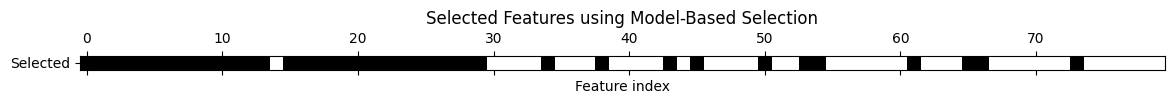

In [22]:
mask = select_model.get_support()

plt.figure(figsize=(14, 4))
plt.matshow(mask.reshape(1, -1), cmap='gray_r', fignum=False)
plt.xlabel("Feature index")
plt.yticks([0], ["Selected"])
plt.title("Selected Features using Model-Based Selection")
plt.show()

In [23]:
logreg = LogisticRegression(max_iter=10000)
logreg.fit(X_train_model, y_train)

print("Score with model-based selected features:", logreg.score(X_test_model, y_test))

Score with model-based selected features: 0.951048951048951


### 6.3 Iterative Feature Selection

Pendekatan iterative melakukan seleksi fitur secara bertahap:
- menambahkan fitur satu per satu (**forward selection**), atau
- menghapus fitur satu per satu (**backward elimination**)

Metode ini bisa menghasilkan subset fitur yang baik, tetapi biasanya lebih mahal secara komputasi.

Pada notebook ini, kita tidak menjalankan iterative feature selection penuh karena prosesnya relatif lebih berat. Namun secara konsep:

- **Forward Selection**: mulai dari 0 fitur, lalu tambahkan fitur yang paling meningkatkan performa.
- **Backward Elimination**: mulai dari semua fitur, lalu buang fitur yang paling tidak penting.
- **Recursive Feature Elimination (RFE)**: model dilatih berulang sambil menghapus fitur dengan bobot paling kecil.

Metode-metode ini sering digunakan ketika interpretasi model sangat penting.

# 7. Summary of Chapter 4

Chapter 4 menekankan bahwa kualitas representasi data sangat memengaruhi performa model machine learning. Beberapa poin penting dari chapter ini:

1. **Categorical variables** tidak bisa langsung digunakan oleh banyak model, sehingga perlu diubah menjadi representasi numerik seperti **one-hot encoding**.
2. **Binning / discretization** dapat membantu model linear menangkap pola non-linear dengan membagi fitur kontinu menjadi interval.
3. **Polynomial and interaction features** memungkinkan model sederhana seperti linear regression menangkap hubungan yang lebih kompleks.
4. **Feature selection** membantu mengurangi noise, mempercepat pelatihan, dan meningkatkan interpretasi model.
5. Machine learning tidak hanya tentang memilih algoritma, tetapi juga tentang bagaimana merepresentasikan data dengan cara yang tepat.

Secara keseluruhan, chapter ini menunjukkan bahwa **feature engineering** adalah salah satu bagian paling penting dalam machine learning praktis.